

## Dataset
- Split the dataset into **80% Training** and **20% Testing** using stratified sampling.
- Keep the **test set completely untouched** until final evaluation.

## Models
- Logistic Regression
- Random Forest

## Experiments for Each Model

### Experiment 1 — No Balancing
- Train the model on the original imbalanced training data.
- Perform **Stratified 5-Fold Cross-Validation**.
- Perform **GridSearchCV** for hyperparameter tuning.
- Select the best model based on **PR-AUC**.
- Refit the best model on the complete training data.
- Evaluate on the untouched test set.

### Experiment 2 — Class Weighting
- Apply `class_weight="balanced"` during model training.
- Perform **Stratified 5-Fold Cross-Validation**.
- Perform **GridSearchCV** for hyperparameter tuning.
- Select the best model based on **PR-AUC**.
- Refit the best model on the complete training data.
- Evaluate on the untouched test set.

### Experiment 3 — SMOTE
- Apply **SMOTE only within the training folds** using an imbalanced-learn pipeline.
- Perform **Stratified 5-Fold Cross-Validation**.
- Perform **GridSearchCV** for hyperparameter tuning.
- Select the best model based on **PR-AUC**.
- Refit the best pipeline on the complete training data.
- Evaluate on the untouched test set.

## Evaluation Metrics
- Precision
- Recall
- F1-Score
- ROC-AUC
- PR-AUC
- Confusion Matrix

## Final Model Comparison
- Compare all three experiments for each model.
- Compare the best experiment from **Logistic Regression** against the best experiment from **Random Forest**.
- Select the final model based on overall performance, with emphasis on **Recall, F1-Score, and PR-AUC** for imbalanced machine-failure detection.

#### logistic regression 

In [1]:
# ============================================================
# 1. LOAD DATA
# ============================================================

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    make_scorer,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE


DATA_PATH = "../data/processed/data_split"

X_train = pd.read_csv(f"{DATA_PATH}/X_train_scaled.csv")
X_test = pd.read_csv(f"{DATA_PATH}/X_test_scaled.csv")

y_train = pd.read_csv(f"{DATA_PATH}/y_train.csv").squeeze()
y_test = pd.read_csv(f"{DATA_PATH}/y_test.csv").squeeze()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (8000, 9)
X_test : (2000, 9)


In [2]:
# ============================================================
# 2. CROSS-VALIDATION AND SCORING
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "precision": make_scorer(
        precision_score,
        zero_division=0
    ),
    "recall": make_scorer(
        recall_score,
        zero_division=0
    ),
    "f1": make_scorer(
        f1_score,
        zero_division=0
    ),
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}

In [3]:
# ============================================================
# 3. EXPERIMENT 1 — NO BALANCING
# ============================================================

lr_no_balance = Pipeline([
    (
        "model",
        LogisticRegression(
            solver="liblinear",
            max_iter=2000,
            random_state=42
        )
    )
])

grid_no_balance = GridSearchCV(
    estimator=lr_no_balance,
    param_grid=param_grid,
    scoring=scoring,
    refit="pr_auc",
    cv=cv,
    n_jobs=-1
)

grid_no_balance.fit(X_train, y_train)

best_lr_no_balance = grid_no_balance.best_estimator_

print("Best Parameters:", grid_no_balance.best_params_)
print("Best CV PR-AUC:", grid_no_balance.best_score_)

Best Parameters: {'model__C': 1}
Best CV PR-AUC: 0.49954519355634874


In [4]:
# ============================================================
# 4. EVALUATION — NO BALANCING
# ============================================================

y_pred_no_balance = best_lr_no_balance.predict(X_test)
y_prob_no_balance = best_lr_no_balance.predict_proba(X_test)[:, 1]

no_balance_results = {
    "Experiment": "No Balancing",
    "Best C": grid_no_balance.best_params_["model__C"],
    "CV PR-AUC": grid_no_balance.best_score_,
    "Test Precision": precision_score(
        y_test, y_pred_no_balance, zero_division=0
    ),
    "Test Recall": recall_score(
        y_test, y_pred_no_balance, zero_division=0
    ),
    "Test F1": f1_score(
        y_test, y_pred_no_balance, zero_division=0
    ),
    "Test ROC-AUC": roc_auc_score(
        y_test, y_prob_no_balance
    ),
    "Test PR-AUC": average_precision_score(
        y_test, y_prob_no_balance
    )
}

pd.DataFrame([no_balance_results])

,Experiment,Best C,CV PR-AUC,Test Precision,Test Recall,Test F1,Test ROC-AUC,Test PR-AUC
0,No Balancing,1,0.499545,0.6,0.176471,0.272727,0.92561,0.464225


In [5]:
# ============================================================
# 5. EXPERIMENT 2 — CLASS WEIGHTING
# ============================================================

lr_weight = Pipeline([
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            solver="liblinear",
            max_iter=2000,
            random_state=42
        )
    )
])

grid_weight = GridSearchCV(
    estimator=lr_weight,
    param_grid=param_grid,
    scoring=scoring,
    refit="pr_auc",
    cv=cv,
    n_jobs=-1
)

grid_weight.fit(X_train, y_train)

best_lr_weight = grid_weight.best_estimator_

print("Best Parameters:", grid_weight.best_params_)
print("Best CV PR-AUC:", grid_weight.best_score_)

Best Parameters: {'model__C': 0.1}
Best CV PR-AUC: 0.4868494877258033


In [6]:
# ============================================================
# 6. EVALUATION — CLASS WEIGHTING
# ============================================================

y_pred_weight = best_lr_weight.predict(X_test)
y_prob_weight = best_lr_weight.predict_proba(X_test)[:, 1]

weight_results = {
    "Experiment": "Class Weighting",
    "Best C": grid_weight.best_params_["model__C"],
    "CV PR-AUC": grid_weight.best_score_,
    "Test Precision": precision_score(
        y_test, y_pred_weight, zero_division=0
    ),
    "Test Recall": recall_score(
        y_test, y_pred_weight, zero_division=0
    ),
    "Test F1": f1_score(
        y_test, y_pred_weight, zero_division=0
    ),
    "Test ROC-AUC": roc_auc_score(
        y_test, y_prob_weight
    ),
    "Test PR-AUC": average_precision_score(
        y_test, y_prob_weight
    )
}

pd.DataFrame([weight_results])

,Experiment,Best C,CV PR-AUC,Test Precision,Test Recall,Test F1,Test ROC-AUC,Test PR-AUC
0,Class Weighting,0.1,0.486849,0.169014,0.882353,0.283688,0.93202,0.448345


In [7]:
# ============================================================
# 7. EXPERIMENT 3 — SMOTE
# ============================================================

lr_smote = ImbPipeline([
    (
        "smote",
        SMOTE(random_state=42)
    ),
    (
        "model",
        LogisticRegression(
            solver="liblinear",
            max_iter=2000,
            random_state=42
        )
    )
])

grid_smote = GridSearchCV(
    estimator=lr_smote,
    param_grid=param_grid,
    scoring=scoring,
    refit="pr_auc",
    cv=cv,
    n_jobs=-1
)

grid_smote.fit(X_train, y_train)

best_lr_smote = grid_smote.best_estimator_

print("Best Parameters:", grid_smote.best_params_)
print("Best CV PR-AUC:", grid_smote.best_score_)

Best Parameters: {'model__C': 0.1}
Best CV PR-AUC: 0.46879042047963965


In [8]:
# ============================================================
# 8. EVALUATION — SMOTE
# ============================================================

y_pred_smote = best_lr_smote.predict(X_test)
y_prob_smote = best_lr_smote.predict_proba(X_test)[:, 1]

smote_results = {
    "Experiment": "SMOTE",
    "Best C": grid_smote.best_params_["model__C"],
    "CV PR-AUC": grid_smote.best_score_,
    "Test Precision": precision_score(
        y_test, y_pred_smote, zero_division=0
    ),
    "Test Recall": recall_score(
        y_test, y_pred_smote, zero_division=0
    ),
    "Test F1": f1_score(
        y_test, y_pred_smote, zero_division=0
    ),
    "Test ROC-AUC": roc_auc_score(
        y_test, y_prob_smote
    ),
    "Test PR-AUC": average_precision_score(
        y_test, y_prob_smote
    )
}

pd.DataFrame([smote_results])

,Experiment,Best C,CV PR-AUC,Test Precision,Test Recall,Test F1,Test ROC-AUC,Test PR-AUC
0,SMOTE,0.1,0.46879,0.183486,0.882353,0.303797,0.930954,0.390212


In [9]:
# ============================================================
# 9. FINAL COMPARISON OF ALL 3 EXPERIMENTS
# ============================================================

comparison_df = pd.DataFrame([
    no_balance_results,
    weight_results,
    smote_results
])

comparison_df = comparison_df.sort_values(
    by="Test PR-AUC",
    ascending=False
).reset_index(drop=True)

comparison_df

,Experiment,Best C,CV PR-AUC,Test Precision,Test Recall,Test F1,Test ROC-AUC,Test PR-AUC
0,No Balancing,1.0,0.499545,0.600000,0.176471,0.272727,0.925610,0.464225
1,Class Weighting,0.1,0.486849,0.169014,0.882353,0.283688,0.932020,0.448345
2,SMOTE,0.1,0.468790,0.183486,0.882353,0.303797,0.930954,0.390212


In [19]:
# Logistic Regression — Best Experiment (SMOTE)

print("Logistic Regression — SMOTE")
print(confusion_matrix(y_test, y_pred_smote))

Logistic Regression — SMOTE
[[1898   34]
 [   9   59]]


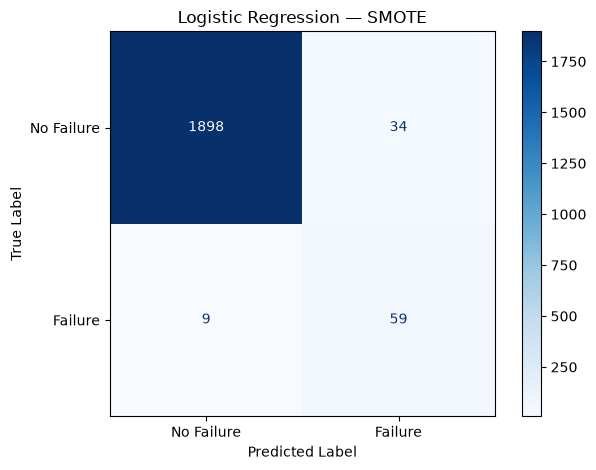

In [23]:
# Logistic Regression — SMOTE

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_smote,
    display_labels=["No Failure", "Failure"],
    values_format="d",
    cmap="Blues"
)

plt.title("Logistic Regression — SMOTE")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

If **Logistic Regression is selected**, go with **SMOTE**. It gives the same high recall (**88.24%**) as class weighting but achieves a slightly better **F1-score (0.304)** and precision (**18.35%**), making it the better-balanced choice for failure detection.


### random forest 

In [10]:
# ============================================================
# 1. LOAD DATA
# ============================================================

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    make_scorer,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE


DATA_PATH = "../data/processed/data_split"

X_train = pd.read_csv(f"{DATA_PATH}/X_train_scaled.csv")
X_test = pd.read_csv(f"{DATA_PATH}/X_test_scaled.csv")

y_train = pd.read_csv(f"{DATA_PATH}/y_train.csv").squeeze()
y_test = pd.read_csv(f"{DATA_PATH}/y_test.csv").squeeze()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (8000, 9)
X_test : (2000, 9)


In [11]:
# ============================================================
# 2. CROSS-VALIDATION AND SCORING
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "precision": make_scorer(
        precision_score,
        zero_division=0
    ),
    "recall": make_scorer(
        recall_score,
        zero_division=0
    ),
    "f1": make_scorer(
        f1_score,
        zero_division=0
    ),
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

In [12]:
# ============================================================
# 3. EXPERIMENT 1 — NO BALANCING
# ============================================================

rf_no_balance = ImbPipeline([
    (
        "model",
        RandomForestClassifier(
            random_state=42,
            n_jobs=-1
        )
    )
])

grid_no_balance = GridSearchCV(
    estimator=rf_no_balance,
    param_grid=param_grid,
    scoring=scoring,
    refit="pr_auc",
    cv=cv,
    n_jobs=-1
)

grid_no_balance.fit(X_train, y_train)

best_rf_no_balance = grid_no_balance.best_estimator_

print("Best Parameters:", grid_no_balance.best_params_)
print("Best CV PR-AUC:", grid_no_balance.best_score_)

Best Parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV PR-AUC: 0.9059745202894872


In [13]:
# ============================================================
# 4. EVALUATION — NO BALANCING
# ============================================================

y_pred_no_balance = best_rf_no_balance.predict(X_test)
y_prob_no_balance = best_rf_no_balance.predict_proba(X_test)[:, 1]

no_balance_results = {
    "Experiment": "No Balancing",
    "Best Parameters": grid_no_balance.best_params_,
    "CV PR-AUC": grid_no_balance.best_score_,
    "Test Precision": precision_score(
        y_test, y_pred_no_balance, zero_division=0
    ),
    "Test Recall": recall_score(
        y_test, y_pred_no_balance, zero_division=0
    ),
    "Test F1": f1_score(
        y_test, y_pred_no_balance, zero_division=0
    ),
    "Test ROC-AUC": roc_auc_score(
        y_test, y_prob_no_balance
    ),
    "Test PR-AUC": average_precision_score(
        y_test, y_prob_no_balance
    )
}

pd.DataFrame([no_balance_results])

,Experiment,Best Parameters,CV PR-AUC,Test Precision,Test Recall,Test F1,Test ROC-AUC,Test PR-AUC
0,No Balancing,"{'model__max_depth': 10, 'model__min_samples_l...",0.905975,0.965517,0.823529,0.888889,0.984198,0.899102


In [14]:
# ============================================================
# 5. EXPERIMENT 2 — CLASS WEIGHTING
# ============================================================

rf_weight = ImbPipeline([
    (
        "model",
        RandomForestClassifier(
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    )
])

grid_weight = GridSearchCV(
    estimator=rf_weight,
    param_grid=param_grid,
    scoring=scoring,
    refit="pr_auc",
    cv=cv,
    n_jobs=-1
)

grid_weight.fit(X_train, y_train)

best_rf_weight = grid_weight.best_estimator_

print("Best Parameters:", grid_weight.best_params_)
print("Best CV PR-AUC:", grid_weight.best_score_)

Best Parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Best CV PR-AUC: 0.8921753817473428


In [15]:
# ============================================================
# 6. EVALUATION — CLASS WEIGHTING
# ============================================================

y_pred_weight = best_rf_weight.predict(X_test)
y_prob_weight = best_rf_weight.predict_proba(X_test)[:, 1]

weight_results = {
    "Experiment": "Class Weighting",
    "Best Parameters": grid_weight.best_params_,
    "CV PR-AUC": grid_weight.best_score_,
    "Test Precision": precision_score(
        y_test, y_pred_weight, zero_division=0
    ),
    "Test Recall": recall_score(
        y_test, y_pred_weight, zero_division=0
    ),
    "Test F1": f1_score(
        y_test, y_pred_weight, zero_division=0
    ),
    "Test ROC-AUC": roc_auc_score(
        y_test, y_prob_weight
    ),
    "Test PR-AUC": average_precision_score(
        y_test, y_prob_weight
    )
}

pd.DataFrame([weight_results])

,Experiment,Best Parameters,CV PR-AUC,Test Precision,Test Recall,Test F1,Test ROC-AUC,Test PR-AUC
0,Class Weighting,"{'model__max_depth': 10, 'model__min_samples_l...",0.892175,0.634409,0.867647,0.732919,0.984723,0.866017


In [16]:
# ============================================================
# 7. EXPERIMENT 3 — SMOTE
# ============================================================

rf_smote = ImbPipeline([
    (
        "smote",
        SMOTE(random_state=42)
    ),
    (
        "model",
        RandomForestClassifier(
            random_state=42,
            n_jobs=-1
        )
    )
])

grid_smote = GridSearchCV(
    estimator=rf_smote,
    param_grid=param_grid,
    scoring=scoring,
    refit="pr_auc",
    cv=cv,
    n_jobs=-1
)

grid_smote.fit(X_train, y_train)

best_rf_smote = grid_smote.best_estimator_

print("Best Parameters:", grid_smote.best_params_)
print("Best CV PR-AUC:", grid_smote.best_score_)

Best Parameters: {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 300}
Best CV PR-AUC: 0.8735146553108301


In [17]:
# ============================================================
# 8. EVALUATION — SMOTE
# ============================================================

y_pred_smote = best_rf_smote.predict(X_test)
y_prob_smote = best_rf_smote.predict_proba(X_test)[:, 1]

smote_results = {
    "Experiment": "SMOTE",
    "Best Parameters": grid_smote.best_params_,
    "CV PR-AUC": grid_smote.best_score_,
    "Test Precision": precision_score(
        y_test, y_pred_smote, zero_division=0
    ),
    "Test Recall": recall_score(
        y_test, y_pred_smote, zero_division=0
    ),
    "Test F1": f1_score(
        y_test, y_pred_smote, zero_division=0
    ),
    "Test ROC-AUC": roc_auc_score(
        y_test, y_prob_smote
    ),
    "Test PR-AUC": average_precision_score(
        y_test, y_prob_smote
    )
}

pd.DataFrame([smote_results])

,Experiment,Best Parameters,CV PR-AUC,Test Precision,Test Recall,Test F1,Test ROC-AUC,Test PR-AUC
0,SMOTE,"{'model__max_depth': None, 'model__min_samples...",0.873515,0.634409,0.867647,0.732919,0.986832,0.882113


In [18]:
# ============================================================
# 9. FINAL COMPARISON OF ALL 3 EXPERIMENTS
# ============================================================

comparison_df = pd.DataFrame([
    no_balance_results,
    weight_results,
    smote_results
])

comparison_df = comparison_df.sort_values(
    by="Test PR-AUC",
    ascending=False
).reset_index(drop=True)

comparison_df

,Experiment,Best Parameters,CV PR-AUC,Test Precision,Test Recall,Test F1,Test ROC-AUC,Test PR-AUC
0,No Balancing,"{'model__max_depth': 10, 'model__min_samples_l...",0.905975,0.965517,0.823529,0.888889,0.984198,0.899102
1,SMOTE,"{'model__max_depth': None, 'model__min_samples...",0.873515,0.634409,0.867647,0.732919,0.986832,0.882113
2,Class Weighting,"{'model__max_depth': 10, 'model__min_samples_l...",0.892175,0.634409,0.867647,0.732919,0.984723,0.866017


In [20]:
# Random Forest — Best Experiment (No Balancing)

print("Random Forest — No Balancing")
print(confusion_matrix(y_test, y_pred_no_balance))

Random Forest — No Balancing
[[1930    2]
 [  12   56]]


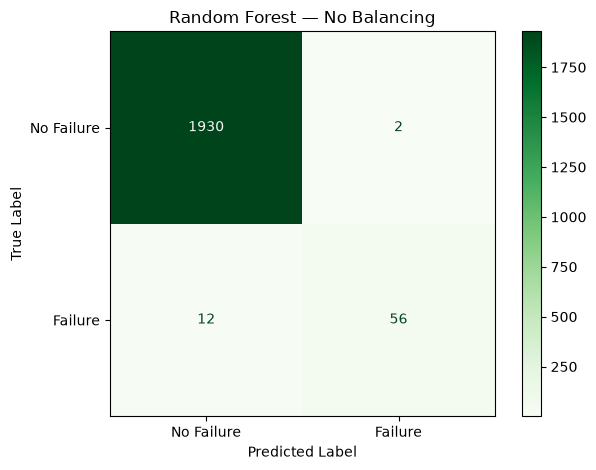

In [24]:
# Random Forest — No Balancing

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_no_balance,
    display_labels=["No Failure", "Failure"],
    values_format="d",
    cmap="Greens"
)

plt.title("Random Forest — No Balancing")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


**Random Forest with No Balancing is the best experiment**, achieving **96.55% precision, 82.35% recall, 0.889 F1-score, and 0.899 PR-AUC**.
It provides the strongest overall balance between detecting failures and minimizing false alarms, so **we can proceed with No Balancing if Random Forest is selected**.
